In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Load the birdnet predictions and validation results

PROB_CORRECT = 0.99

df_pred = pd.read_csv("data/raw/Data Birds/birdnet_predictions.csv")
df_val = pd.read_csv("data/raw/Data Birds/validation_results.csv")

In [3]:
df_pred.shape

(29491, 13)

In [4]:
df_pred.head()

,selection,view,channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,common_name,species_code,confidence,begin_path,file_offset_s,folder
0,1,Spectrogram 1,1,889,892,0,15000,African Black-headed Oriole,abhori1,0.6278,Grid2/RBS02/RBS02_20230622_170000.WAV,889,RBS02
1,2,Spectrogram 1,1,1084,1087,0,15000,African Black-headed Oriole,abhori1,0.3217,Grid2/RBS02/RBS02_20230622_170000.WAV,1084,RBS02
2,1,Spectrogram 1,1,3178,3181,0,15000,Abyssinian Nightjar,abynig1,0.1028,Grid2/RBS02/RBS02_20230622_190000.WAV,3178,RBS02
3,2,Spectrogram 1,1,3574,3577,0,15000,Abyssinian Nightjar,abynig1,0.1456,Grid2/RBS02/RBS02_20230622_190000.WAV,3574,RBS02
4,1,Spectrogram 1,1,1533,1536,0,15000,Abyssinian Nightjar,abynig1,0.1129,Grid2/RBS02/RBS02_20230623_190000.WAV,1533,RBS02


In [5]:
# What proportion of each species is in the dataset

df_pred[["common_name", "species_code"]].value_counts()

common_name                  species_code
African Black-headed Oriole  abhori1         18054
Abyssinian Nightjar          abynig1         10187
Three-banded Plover          thbplo1          1015
Red-billed Firefinch         rebfir2           235
Name: count, dtype: int64

In [6]:
df_pred.groupby("common_name")["confidence"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
common_name,,,,
Abyssinian Nightjar,10187.0,0.1000,0.3223,1.0000
African Black-headed Oriole,18054.0,0.1000,0.2787,0.9985
Red-billed Firefinch,235.0,0.1000,0.1369,0.9073
Three-banded Plover,1015.0,0.1002,0.2858,0.9997


In [7]:
df_val.shape

(551, 6)

In [8]:
df_val.head()

,scientificName,commonName,vBirdNET,filename,confidence,outcome
0,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.107_4_RBS21_20230630_190000.wav,0.107,1
1,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.109_1_RBS14_20230706_010000.wav,0.109,1
2,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.110_1_RBS60_20230702_220000.wav,0.110,1
3,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.113_3_RBS14_20230708_040002.wav,0.113,1
4,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.116_1_RBS55_20230701_220000.wav,0.116,1


In [9]:
df_val[["scientificName", "commonName", "outcome"]].value_counts(sort=False)

scientificName             commonName                   outcome
Caprimulgus poliocephalus  Abyssinian Nightjar          1          117
                                                        0           33
Oriolus larvatus           African Black-headed Oriole  1          150
Lagonosticta senegala      Red-billed Firefinch         1            6
                                                        0           95
Charadrius tricollaris     Three-banded Plover          1          149
                                                        0            1
Name: count, dtype: int64

In [10]:
def logit(p: np.ndarray, eps: float=1e-6) -> np.ndarray:
    # Clip confidence values of 1 which will cause div by zero errors
    p = np.clip(p, a_min=0, a_max=1 - eps)
    return np.log(p / (1 - p))

df_val["logit_score"] = logit(df_val["confidence"])

In [11]:
df_val

,scientificName,commonName,vBirdNET,filename,confidence,outcome,logit_score
0,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.107_4_RBS21_20230630_190000.wav,0.107,1,-2.121758
1,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.109_1_RBS14_20230706_010000.wav,0.109,1,-2.100997
2,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.110_1_RBS60_20230702_220000.wav,0.110,1,-2.090741
3,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.113_3_RBS14_20230708_040002.wav,0.113,1,-2.060457
4,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.116_1_RBS55_20230701_220000.wav,0.116,1,-2.030867
...,...,...,...,...,...,...,...
546,Charadrius tricollaris,Three-banded Plover,v2.4,0.989_6_RBS75_20230702_080002.wav,0.989,1,4.498799
547,Charadrius tricollaris,Three-banded Plover,v2.4,0.991_1_RBS75_20230701_000000.wav,0.991,1,4.701490
548,Charadrius tricollaris,Three-banded Plover,v2.4,0.991_1_RBS75_20230707_110002.wav,0.991,1,4.701490
549,Charadrius tricollaris,Three-banded Plover,v2.4,0.994_4_RBS75_20230628_160000.wav,0.994,1,5.109978


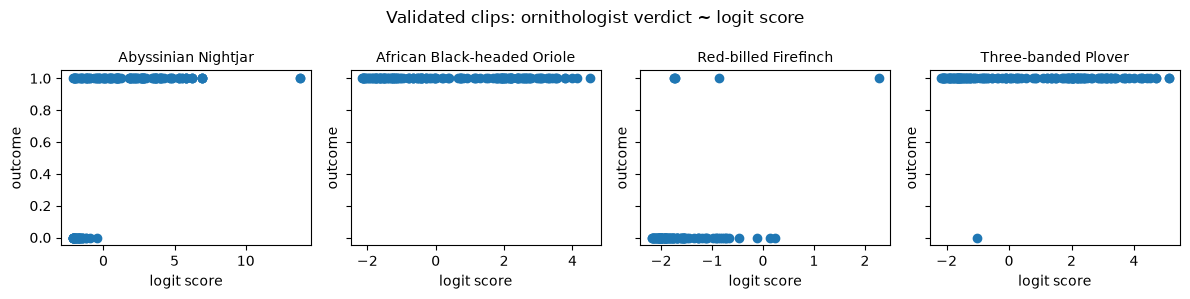

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

i=0
for species, df_species_val in df_val.groupby("commonName"):
    ax[i].scatter(df_species_val["logit_score"], df_species_val["outcome"])
    ax[i].set_title(species, fontsize=10)
    ax[i].set_xlabel("logit score")
    ax[i].set_ylabel("outcome")
    i+=1
fig.suptitle("Validated clips: ornithologist verdict ~ logit score")
fig.tight_layout()

## first pass - fitting and plotting each species without checks

In [13]:
results = {}
thresholds = {}
for species, df_species_val in df_val.groupby("commonName"):
    
    glm_model = smf.glm("outcome ~ logit_score", data=df_species_val, family=sm.families.Binomial())
    result = glm_model.fit()
    
    b0, b1 = result.params
    threshold_logit = (np.log(PROB_CORRECT / (1 - PROB_CORRECT)) - b0) / b1

    results[species] = result
    thresholds[species] = threshold_logit

/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


/home/nick/repos/natural-state-task/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


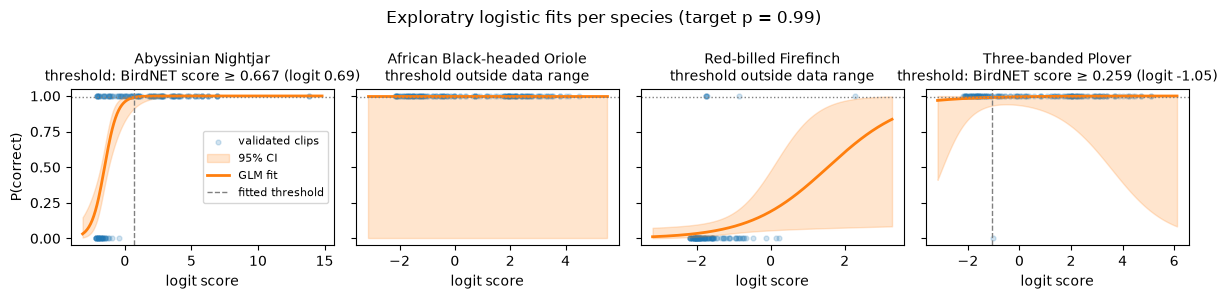

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

for ax, (species, df_species_val) in zip(axes, df_val.groupby("commonName")):
    result = results[species]

    x_grid = np.linspace(df_species_val["logit_score"].min() - 1, df_species_val["logit_score"].max() + 1, 300)
    # Get predictions from the GLM across the x grid, and include the 95% confidence interval
    pred = result.get_prediction(pd.DataFrame({"logit_score": x_grid})).summary_frame(alpha=0.05)

    ax.scatter(df_species_val["logit_score"], df_species_val["outcome"], s=12, alpha=0.2, color="C0", label="validated clips")
    ax.fill_between(x_grid, pred["mean_ci_lower"], pred["mean_ci_upper"], color="C1", alpha=0.2, label="95% CI")
    ax.plot(x_grid, pred["mean"], color="C1", lw=2, label="GLM fit")
    ax.axhline(PROB_CORRECT, color="grey", ls=":", lw=1)

    # plot the threshold logit for each species
    t = thresholds[species]
    if df_species_val["logit_score"].min() <= t <= df_species_val["logit_score"].max():
        ax.axvline(t, color="grey", ls="--", lw=1, label="fitted threshold")
        ax.set_title(f"{species}\nthreshold: BirdNET score ≥ {1 / (1 + np.exp(-t)):.3f} (logit {t:.2f})", fontsize=10)

    else:
        ax.set_title(f"{species}\nthreshold outside data range", fontsize=10)
    ax.set_xlabel("logit score")

axes[0].set_ylabel("P(correct)")
axes[0].legend(fontsize=8, loc="center right")

fig.suptitle(f"Exploratry logistic fits per species (target p = {PROB_CORRECT})")
fig.tight_layout()

In [19]:
## first pass - fitting and plotting each species without checks

In [ ]:
def fit_threshold(df_species_val: pd.DataFrame, prob_correct: float) -> dict:
    """Fit outcome ~ logit_score for one species and return the threshold plus a status flag."""

    n = len(df_species_val)
    n_correct = int(df_species_val["outcome"].sum())
    row = {
        "n_validated": n,
        "n_correct": n_correct,
        "n_incorrect": n - n_correct,
        "b0": np.nan,
        "b1": np.nan,
        "b1_ci_low": np.nan,
        "b1_ci_high": np.nan,
        "threshold_logit": np.nan,
        "threshold_conf": np.nan
    }

    # To fit a curve, need both correct and incorrect clips
    if row["n_incorrect"] == 0:
        return {**row, "status": "no_negatives"}
    if n_correct == 0:
        return {**row, "status": "no_positives"}

    result = smf.glm("outcome ~ logit_score", data=df_species_val, family=sm.families.Binomial()).fit()

    b0, b1 = result.params
    ci_low, ci_high = result.conf_int().loc["logit_score"]
    threshold_logit = (np.log(prob_correct / (1 - prob_correct)) - b0) / b1
    row.update({
        "b0": b0,"b1": b1, "b1_ci_low": ci_low, "b1_ci_high": ci_high,
        "threshold_logit": threshold_logit,
        "threshold_conf": 1 / (1 + np.exp(-threshold_logit))
    })

    # Only trust the threshold if score genuinely predicts correctness
    if ci_low <= 0:
        return {**row, "status": "unreliable_fit"}
    
    # Only trust the threshold it lies within the validated values
    if row["threshold_conf"] > df_species_val["confidence"].max():
        return {**row, "status": "threshold_above_validated_scores"}
    return {**row, "status": "fitted"}


rows = []
for species, df_species_val in df_val.groupby("commonName"):
    species_result = fit_threshold(df_species_val, PROB_CORRECT)
    species_result["species"] = species
    rows.append(species_result)

thresholds_df = pd.DataFrame(rows)
thresholds_df["threshold_usable"] = thresholds_df["status"] == "fitted"
thresholds_df

,n_validated,n_correct,n_incorrect,b0,b1,b1_ci_low,b1_ci_high,threshold_logit,threshold_conf,status,species,threshold_usable
0,150,117,33,3.158998,2.072270,1.101095,3.043445,0.693018,0.666638,fitted,Abyssinian Nightjar,True
1,150,150,0,NaN,NaN,NaN,NaN,NaN,NaN,no_negatives,African Black-headed Oriole,False
2,101,6,95,-1.457779,0.942296,0.067225,1.817366,6.423567,0.998380,threshold_above_validated_scores,Red-billed Firefinch,False
3,150,149,1,5.170345,0.546686,-0.957232,2.050604,-1.052204,0.258802,unreliable_fit,Three-banded Plover,False


In [16]:
df_obs = pd.merge(
    df_pred,
    thresholds_df[["threshold_conf", "threshold_usable", "species"]],
    left_on="common_name",
    right_on="species",
    how="left"
)
df_obs.drop(columns="species", inplace=True)
is_observation = df_obs["threshold_usable"] & (df_obs["confidence"] >= df_obs["threshold_conf"])
df_obs["observation"] = df_obs["common_name"].where(is_observation)

df_obs.groupby("common_name").agg(
    predictions=("confidence", "size"),
    observations=("observation", "count"),
    threshold_usable=("threshold_usable", "first"),
)

,predictions,observations,threshold_usable
common_name,,,
Abyssinian Nightjar,10187,3147,True
African Black-headed Oriole,18054,0,False
Red-billed Firefinch,235,0,False
Three-banded Plover,1015,0,False


In [17]:
df_obs

,selection,view,channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,common_name,species_code,confidence,begin_path,file_offset_s,folder,threshold_conf,threshold_usable,observation
0,1,Spectrogram 1,1,889,892,0,15000,African Black-headed Oriole,abhori1,0.6278,Grid2/RBS02/RBS02_20230622_170000.WAV,889,RBS02,NaN,False,NaN
1,2,Spectrogram 1,1,1084,1087,0,15000,African Black-headed Oriole,abhori1,0.3217,Grid2/RBS02/RBS02_20230622_170000.WAV,1084,RBS02,NaN,False,NaN
2,1,Spectrogram 1,1,3178,3181,0,15000,Abyssinian Nightjar,abynig1,0.1028,Grid2/RBS02/RBS02_20230622_190000.WAV,3178,RBS02,0.666638,True,NaN
3,2,Spectrogram 1,1,3574,3577,0,15000,Abyssinian Nightjar,abynig1,0.1456,Grid2/RBS02/RBS02_20230622_190000.WAV,3574,RBS02,0.666638,True,NaN
4,1,Spectrogram 1,1,1533,1536,0,15000,Abyssinian Nightjar,abynig1,0.1129,Grid2/RBS02/RBS02_20230623_190000.WAV,1533,RBS02,0.666638,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29486,5,Spectrogram 1,1,1008,1011,0,15000,Abyssinian Nightjar,abynig1,0.1584,Grid2/RBS79/RBS79_20230711_210000.WAV,1008,RBS79,0.666638,True,NaN
29487,6,Spectrogram 1,1,1194,1197,0,15000,Abyssinian Nightjar,abynig1,0.1094,Grid2/RBS79/RBS79_20230711_210000.WAV,1194,RBS79,0.666638,True,NaN
29488,7,Spectrogram 1,1,1209,1212,0,15000,Abyssinian Nightjar,abynig1,0.1103,Grid2/RBS79/RBS79_20230711_210000.WAV,1209,RBS79,0.666638,True,NaN
29489,8,Spectrogram 1,1,1461,1464,0,15000,Abyssinian Nightjar,abynig1,0.2401,Grid2/RBS79/RBS79_20230711_210000.WAV,1461,RBS79,0.666638,True,NaN


In [21]:
df_obs.to_csv("data/processed/birdnet_observations.csv", index=False)

In [23]:
thresholds_df.to_csv("data/processed/species_thresholds.csv")